In [1]:
%pip install opencv-python numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

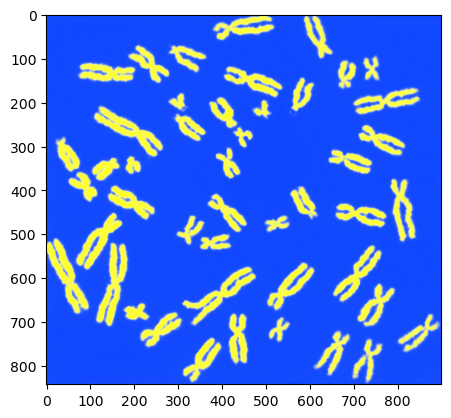

In [3]:
image = cv2.imread('chromosomes.jpg')
# the image was loaded in RGB, but matplotlib uses BGR internally. Fix found on stackoverflow
plt.imshow(image[..., ::-1])

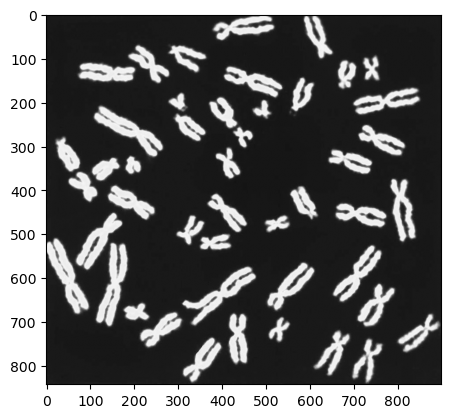

In [4]:
grayscale_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

#need cmap="gray" to display grayscale images correctly, found solution on stackoverflow
plt.imshow(grayscale_image, cmap="gray")

In [5]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
opening = cv2.morphologyEx(grayscale_image, cv2.MORPH_ELLIPSE, kernel)
kernel

array([[1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1]], dtype=uint8)

In [6]:
_, dst = cv2.threshold(opening, 170, 255, cv2.THRESH_BINARY)

In [7]:
contours, hierarchy = cv2.findContours(dst, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [8]:
len(contours)

46

In [9]:
#calculate all the needed values and store ina df
import pandas as pd
info =[]
for i in contours:
    Area= cv2.contourArea(i)
    Perimeter = cv2.arcLength(i, True)
    Circularity = (4* np.pi* Area) / (Perimeter**2) if Perimeter else None
    x, y, w, h = cv2.boundingRect(i)
    image = cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    info.append((h,w,i.shape, Area, Perimeter, Circularity))
df = pd.DataFrame(info, columns=['Height', 'Width', 'Contour Shape', 'Area', 'Perimeter', 'Circularity'])
df

,Height,Width,Contour Shape,Area,Perimeter,Circularity
0,94,64,"(144, 1, 2)",1924.0,410.735062,0.143315
1,98,86,"(218, 1, 2)",2889.5,446.457930,0.182168
2,98,76,"(207, 1, 2)",2298.0,428.617311,0.157188
3,53,45,"(86, 1, 2)",901.0,209.681239,0.257523
4,84,90,"(190, 1, 2)",2003.5,433.002086,0.134282
5,111,42,"(162, 1, 2)",2996.0,470.048770,0.170399
6,77,92,"(158, 1, 2)",2740.0,383.504614,0.234110
7,37,54,"(74, 1, 2)",1237.0,177.681239,0.492375
8,95,82,"(186, 1, 2)",2678.0,456.274165,0.161647
9,131,164,"(258, 1, 2)",5170.0,605.896530,0.176972


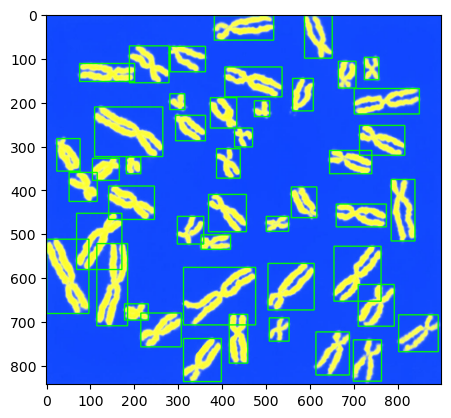

In [10]:
plt.imshow(image[..., ::-1])

# Cleaning and Normalizing

In [11]:
df.dropna(inplace=True)

In [12]:
df_standardized = df.copy()
df_normalized = df.copy()

In [13]:
for col in ['Height', 'Width', 'Area', 'Perimeter', 'Circularity']:
    df_standardized[col] = (df[col] - df[col].mean()) / df[col].std()
    df_normalized[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

In [14]:
for col in ['Height', 'Width', 'Area', 'Perimeter', 'Circularity']:
    df_standardized = df_standardized[df_standardized[col].abs() < 3]

In [15]:
df_standardized

,Height,Width,Contour Shape,Area,Perimeter,Circularity
0,0.467374,-0.432034,"(144, 1, 2)",-0.407292,0.264707,-0.849364
1,0.580677,0.216658,"(218, 1, 2)",0.355428,0.495738,-0.585687
2,0.580677,-0.078202,"(207, 1, 2)",-0.111841,0.380357,-0.755211
3,-0.693980,-0.992268,"(86, 1, 2)",-1.215435,-1.035571,-0.074285
4,0.184117,0.334602,"(190, 1, 2)",-0.344489,0.408715,-0.910664
5,0.948912,-1.080726,"(162, 1, 2)",0.439560,0.648307,-0.665560
6,-0.014163,0.393574,"(158, 1, 2)",0.237327,0.088599,-0.233180
7,-1.147192,-0.726894,"(74, 1, 2)",-0.950004,-1.242525,1.519560
8,0.495700,0.098714,"(186, 1, 2)",0.188349,0.559223,-0.724950
9,1.515426,2.516565,"(258, 1, 2)",2.156963,1.526877,-0.620951


In [16]:
df_normalized

,Height,Width,Contour Shape,Area,Perimeter,Circularity
0,0.396104,0.236641,"(144, 1, 2)",0.259304,0.511617,0.070890
1,0.422078,0.404580,"(218, 1, 2)",0.454060,0.574911,0.143687
2,0.422078,0.328244,"(207, 1, 2)",0.334745,0.543301,0.096885
3,0.129870,0.091603,"(86, 1, 2)",0.052950,0.155386,0.284877
4,0.331169,0.435115,"(190, 1, 2)",0.275340,0.551070,0.053967
5,0.506494,0.068702,"(162, 1, 2)",0.475542,0.616710,0.121636
6,0.285714,0.450382,"(158, 1, 2)",0.423903,0.463369,0.241009
7,0.025974,0.160305,"(74, 1, 2)",0.120726,0.098688,0.724910
8,0.402597,0.374046,"(186, 1, 2)",0.411397,0.592304,0.105239
9,0.636364,1.000000,"(258, 1, 2)",0.914070,0.857407,0.133951


### Q1: How can contour detection be used to identify objects in an image?

Contour detection marks the boundary of each disjoint object in the image. This can detect objects in the image by giving them their individual contours. Unrequired objects can then be filtered out with other tests like color etc.

### Q2: What is the importance of standardization of data? What difference did you observe before and after standardization?

Each category had its own range of values and units. It was hard to understand the outliers and general distribution. Standardization reduced all values to a standard gaussian distribution. It was also easy to remove the outliers by checking for a standard deviation threshold (3 from the mean).


### Q3: Let's consider one of the values in the width column is missing. How to handle this missing value?

In the code, I have dropped such values during cleaning, but we can also replace them by the mean or median or with a regressed value based on other columns.

### Q4: What is the importance of data normalization? What difference did you observe before and after normalization?

Each category had its own range of values and units and it was thus hard to understand the general distribution. Normalization reduced all values to a [0,1] range. This helped me identify the extremity of these values.

### Q5: How might you adapt the bounding box construction process to handle overlapping or touching chromosomes?

In a previous version of my code, I was using a different method to finding contours. It used the RETR_TREE method instead of the RETR_EXTERNAL method. This resulted in my finding contours within other contours. I realised this when I plotted the bounding boxes and realized that I should instead be using RETR_EXTERNAL.